Pips, Imports and folder definition:

In [32]:
!pip install --quiet opencv-python

import cv2
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

input_serrated = r"C:\Users\Admin\Documents\TravailMasterDom\stab_data\train\Serrated"
output_serrated = r"C:\Users\Admin\Documents\TravailMasterDom\semantic_stab_data\train\Serrated"

input_smooth = r"C:\Users\Admin\Documents\TravailMasterDom\stab_data\train\Smooth"
output_smooth = r"C:\Users\Admin\Documents\TravailMasterDom\semantic_stab_data\train\Smooth"

In [33]:
# Debug
print("Folder exists:", os.path.isdir(input_serrated))
print("Files:", os.listdir(input_serrated)[:10])
print("There are ", len(os.listdir(input_serrated)), "files in the serrated folder.")

Folder exists: True
Files: ['Serrated_Cot_KN_1_0001.jpg', 'Serrated_Cot_KN_1_0002.jpg', 'Serrated_Cot_KN_1_0003.jpg', 'Serrated_Cot_KN_1_0004.jpg', 'Serrated_Cot_KN_1_0005.jpg', 'Serrated_Cot_KN_1_0006.jpg', 'Serrated_Cot_KN_1_0007.jpg', 'Serrated_Cot_KN_1_0008.jpg', 'Serrated_Cot_KN_1_0009.jpg', 'Serrated_Cot_KN_2_0001.jpg']
There are  108 files in the serrated folder.


In [34]:
def semantic_segmentation_folder(input_folder, output_folder):
    print("\n--- Running segmentation ---")
    print("Input folder:", input_folder)
    print("Output folder:", output_folder)

    os.makedirs(output_folder, exist_ok=True)

    file_list = os.listdir(input_folder)
    print(f"Found {len(file_list)} files.")

    processed = 0

    for filename in file_list:
        if not filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")):
            print("Skipping non-image:", filename)
            continue

        img_path = os.path.join(input_folder, filename)
        print("Processing:", img_path)

        img = cv2.imread(img_path)
        if img is None:
            print(" -> Failed to load (cv2 returned None)")
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, mask = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

        out_path = os.path.join(output_folder, filename)
        cv2.imwrite(out_path, mask)
        print(" -> Saved to", out_path)

        processed += 1

    print(f"\nDone. Processed {processed} images.")

In [35]:
semantic_segmentation_folder(input_serrated, output_serrated)
semantic_segmentation_folder(input_smooth, output_smooth)


--- Running segmentation ---
Input folder: C:\Users\Admin\Documents\TravailMasterDom\stab_data\train\Serrated
Output folder: C:\Users\Admin\Documents\TravailMasterDom\semantic_stab_data\train\Serrated
Found 108 files.
Processing: C:\Users\Admin\Documents\TravailMasterDom\stab_data\train\Serrated\Serrated_Cot_KN_1_0001.jpg
 -> Saved to C:\Users\Admin\Documents\TravailMasterDom\semantic_stab_data\train\Serrated\Serrated_Cot_KN_1_0001.jpg
Processing: C:\Users\Admin\Documents\TravailMasterDom\stab_data\train\Serrated\Serrated_Cot_KN_1_0002.jpg
 -> Saved to C:\Users\Admin\Documents\TravailMasterDom\semantic_stab_data\train\Serrated\Serrated_Cot_KN_1_0002.jpg
Processing: C:\Users\Admin\Documents\TravailMasterDom\stab_data\train\Serrated\Serrated_Cot_KN_1_0003.jpg
 -> Saved to C:\Users\Admin\Documents\TravailMasterDom\semantic_stab_data\train\Serrated\Serrated_Cot_KN_1_0003.jpg
Processing: C:\Users\Admin\Documents\TravailMasterDom\stab_data\train\Serrated\Serrated_Cot_KN_1_0004.jpg
 -> Saved

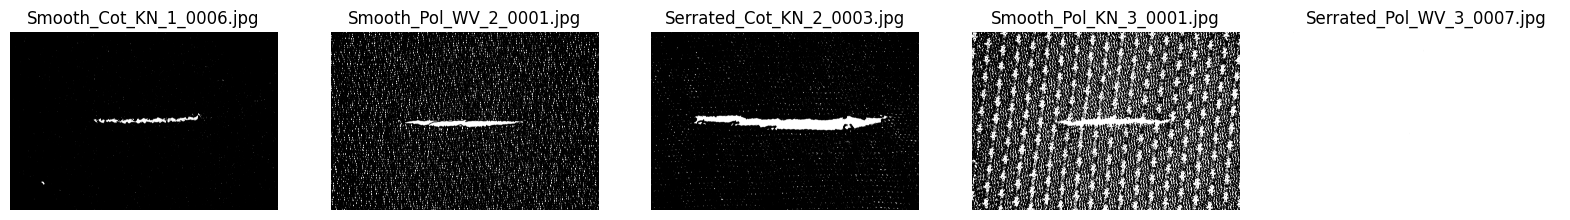

In [ ]:
# Path to semantic dataset
base_dir = r"C:\Users\Admin\Documents\TravailMasterDom\semantic_stab_data\train"

rows = 1
cols = 5

# Collect image paths
image_paths = []

for cls in os.listdir(base_dir):
    cls_dir = os.path.join(base_dir, cls)
    for f in os.listdir(cls_dir):
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            image_paths.append(os.path.join(cls_dir, f))

# Sample images
samples = random.sample(image_paths, rows * cols)

# Plot grid
fig = plt.figure(figsize=(cols * 4, rows * 4))

for idx, img_path in enumerate(samples):
    # Open image
    img = Image.open(img_path)
    
    # Convert to numpy array to check if grayscale
    img_array = np.array(img)
    
    # If single channel (grayscale), display with cmap='gray'
    if len(img_array.shape) == 2:
        display_img = img_array
        cmap = 'gray'
    else:
        display_img = img
        cmap = None  # RGB image
    
    filename = os.path.basename(img_path)  # get filename only

    ax = fig.add_subplot(rows, cols, idx + 1)
    plt.imshow(display_img, cmap=cmap)
    plt.title(filename)  # show filename
    plt.axis('off')

plt.show()

Done so far
Set up input/output folders for Serrated and Smooth images.
Created binary semantic masks using simple thresholding.
Made a Jupyter snippet to display random images with filenames.

Next steps
Apply edge detection to the masks and save the results.
Optionally, overlay masks or edges on original images for visualization.
Later, replace thresholding with a real segmentation model for more accurate masks.

Edge Detection on Masks

The following snippet will:

Load each mask from your semantic dataset folders.
Apply Canny edge detection.
Save the edges in a new output folder, keeping the original filenames.

In [37]:
# Input and output folders
input_folders = [
    r"C:\Users\Admin\Documents\TravailMasterDom\semantic_stab_data\train\Serrated",
    r"C:\Users\Admin\Documents\TravailMasterDom\semantic_stab_data\train\Smooth"
]

output_base = r"C:\Users\Admin\Documents\TravailMasterDom\edges_stab_data\train"

# Edge detection parameters
low_thresh = 50
high_thresh = 150

# Process images
for input_folder in input_folders:
    cls = os.path.basename(input_folder)  # Serrated or Smooth
    output_folder = os.path.join(output_base, cls)
    
    for filename in os.listdir(input_folder):
        if not filename.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
            continue

        img_path = os.path.join(input_folder, filename)
        mask = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            print("Failed to load:", img_path)
            continue

        edges = cv2.Canny(mask, low_thresh, high_thresh)

        output_path = os.path.join(output_folder, filename)
        cv2.imwrite(output_path, edges)

print("Edge detection completed!")

Edge detection completed!


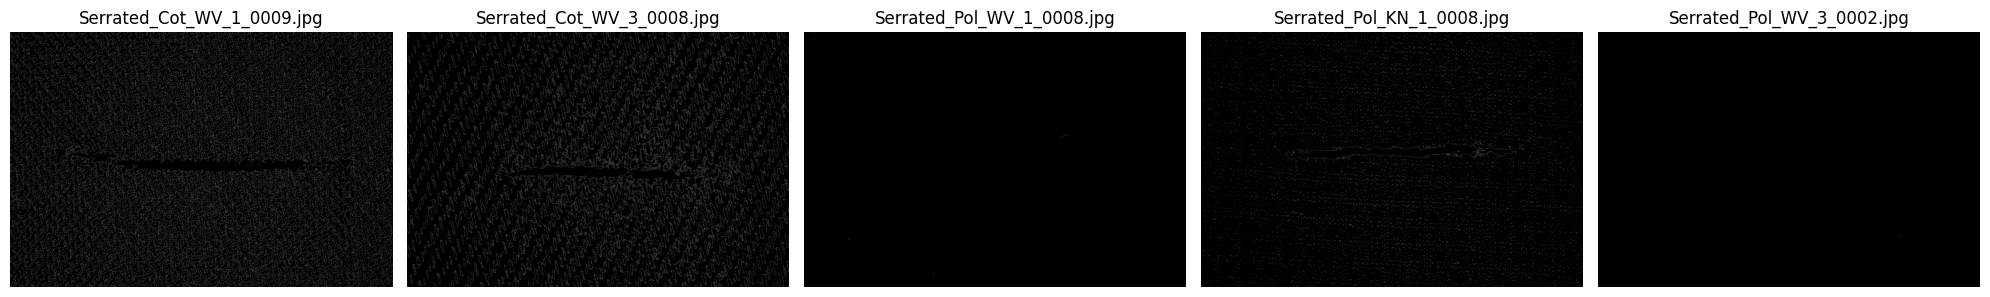

In [40]:
# Ensure plots render inline in Jupyter
%matplotlib inline

# Folder with edge images
edge_folder = r"C:\Users\Admin\Documents\TravailMasterDom\edges_stab_data\train\Serrated"

# List image files
files = [f for f in os.listdir(edge_folder) if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))]

# Pick a few random samples
samples = random.sample(files, min(5, len(files)))

# Create figure
fig, axes = plt.subplots(1, len(samples), figsize=(20, 4))  # 1 row, len(samples) columns

for ax, f in zip(axes, samples):
    img = Image.open(os.path.join(edge_folder, f))
    ax.imshow(img, cmap='gray')
    ax.set_title(f)
    ax.axis('off')

plt.tight_layout()
plt.show()

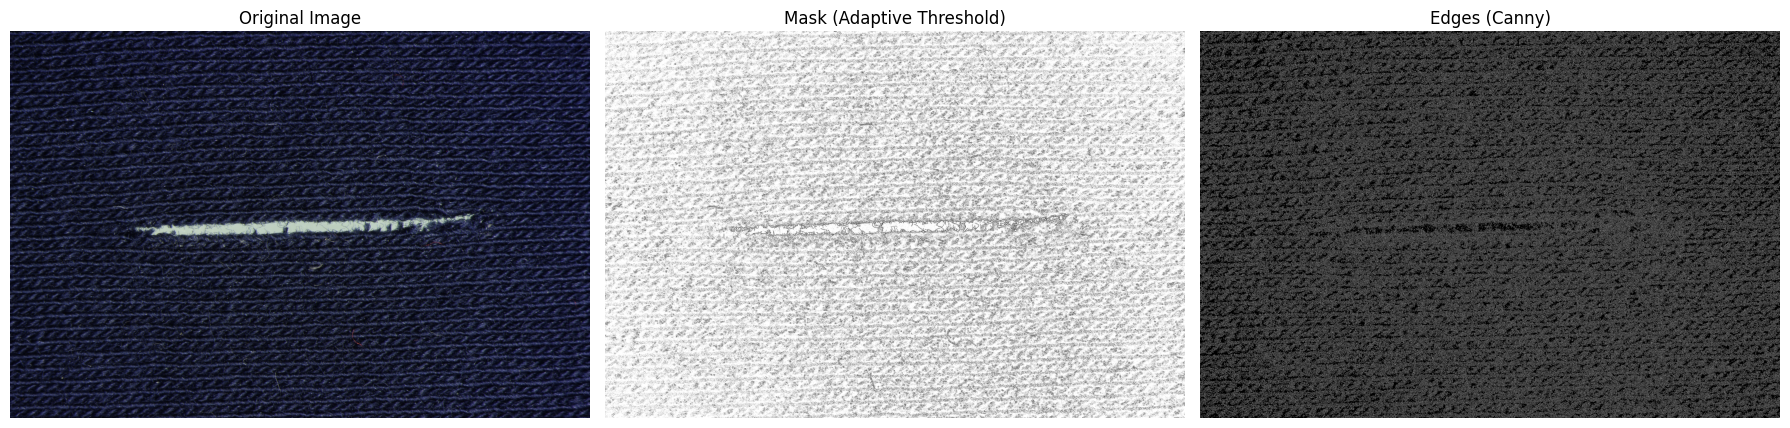

In [80]:
img_path = r"C:\Users\Admin\Documents\TravailMasterDom\stab_data\train\Serrated\Serrated_Cot_KN_1_0001.jpg"
img = Image.open(img_path)
img_array = np.array(img)

# Parameters for adaptive threshold / edge detection
low_thresh = 150
high_thresh = 200

# Convert grayscale to uint8 (needed for cv2 functions)
gray_uint8 = gray.astype(np.uint8)

# Adaptive threshold to get a clean binary mask
mask = cv2.adaptiveThreshold(gray_uint8, 255,
                             cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                             cv2.THRESH_BINARY,
                             5, 2) # blockSize: 11 and C:2 (Original values)

# Edge detection using Canny
edges = cv2.Canny(mask, low_thresh, high_thresh)

# Display all three images side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_array)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title("Mask (Adaptive Threshold)")
axes[1].axis('off')

axes[2].imshow(edges, cmap='gray')
axes[2].set_title("Edges (Canny)")
axes[2].axis('off')

plt.tight_layout()
plt.show()